In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000

df = pd.DataFrame({
    "OrderID": np.arange(10000, 10000+n),
    "CustomerID": np.random.randint(1000, 1200, n),
    "ProductID": np.random.randint(200, 400, n),
    "Product": np.random.choice(["Laptop","Phone","Tablet","Monitor"], n),
    "Category": np.random.choice(["Electronics","Accessories"], n),
    "Region": np.random.choice(["North","South","East","West"], n),
    "OrderDate": np.random.choice(pd.date_range("2023-01-01","2024-12-31"), n),
    "Quantity": np.random.randint(1, 5, n),
    "Price": np.random.uniform(50, 1500, n),
    "Discount": np.random.uniform(0, 0.3, n),
    "PaymentMethod": np.random.choice(["Card","UPI","Cash"], n)
})

df["Revenue"] = df["Quantity"] * df["Price"] * (1 - df["Discount"])

df.to_csv("retail_raw_data.csv", index=False)

df.head()

,OrderID,CustomerID,ProductID,Product,Category,Region,OrderDate,Quantity,Price,Discount,PaymentMethod,Revenue
0,10000,1102,349,Tablet,Electronics,North,2024-06-02,4,1020.555109,0.222542,Card,3173.755169
1,10001,1179,302,Phone,Accessories,North,2024-03-01,3,1255.782193,0.227011,UPI,2912.115682
2,10002,1092,393,Tablet,Accessories,South,2024-07-12,1,267.950403,0.200072,Card,214.341133
3,10003,1014,365,Tablet,Accessories,West,2024-07-18,1,105.957765,0.070208,Cash,98.518634
4,10004,1106,302,Monitor,Accessories,North,2023-07-06,3,1324.377662,0.176426,UPI,3272.169526


In [2]:
import pandas as pd

# Load raw data (simulating extraction step)
df = pd.read_csv("retail_raw_data.csv")

# --- CLEANING (Transform Stage 1) ---

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (if any)
df = df.dropna()

# Validate data
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Convert date
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# --- STAGING TABLE (clean intermediate layer) ---
staging_df = df.copy()

staging_df.head()

,OrderID,CustomerID,ProductID,Product,Category,Region,OrderDate,Quantity,Price,Discount,PaymentMethod,Revenue
0,10000,1102,349,Tablet,Electronics,North,2024-06-02,4,1020.555109,0.222542,Card,3173.755169
1,10001,1179,302,Phone,Accessories,North,2024-03-01,3,1255.782193,0.227011,UPI,2912.115682
2,10002,1092,393,Tablet,Accessories,South,2024-07-12,1,267.950403,0.200072,Card,214.341133
3,10003,1014,365,Tablet,Accessories,West,2024-07-18,1,105.957765,0.070208,Cash,98.518634
4,10004,1106,302,Monitor,Accessories,North,2023-07-06,3,1324.377662,0.176426,UPI,3272.169526


In [3]:
staging_df.shape

(2000, 12)

In [4]:
# ---------------------------
# FACT TABLE
# ---------------------------
fact_sales = staging_df[[
    "OrderID",
    "CustomerID",
    "ProductID",
    "OrderDate",
    "Quantity",
    "Price",
    "Discount",
    "Revenue"
]].copy()

# ---------------------------
# DIMENSION: Customer
# ---------------------------
dim_customer = staging_df[[
    "CustomerID"
]].drop_duplicates()

dim_customer["CustomerSegment"] = np.random.choice(
    ["Bronze", "Silver", "Gold"], len(dim_customer)
)

# ---------------------------
# DIMENSION: Product
# ---------------------------
dim_product = staging_df[[
    "ProductID",
    "Product",
    "Category"
]].drop_duplicates()

# ---------------------------
# DIMENSION: Region
# ---------------------------
dim_region = staging_df[[
    "Region"
]].drop_duplicates()

# ---------------------------
# DIMENSION: Date
# ---------------------------
dim_date = staging_df[["OrderDate"]].drop_duplicates()
dim_date["Year"] = dim_date["OrderDate"].dt.year
dim_date["Month"] = dim_date["OrderDate"].dt.month
dim_date["Day"] = dim_date["OrderDate"].dt.day

# ---------------------------
# CHECK OUTPUTS
# ---------------------------
print("Fact Table:", fact_sales.shape)
print("Customer Dim:", dim_customer.shape)
print("Product Dim:", dim_product.shape)
print("Region Dim:", dim_region.shape)
print("Date Dim:", dim_date.shape)

fact_sales.head()

Fact Table: (2000, 8)
Customer Dim: (200, 2)
Product Dim: (1141, 3)
Region Dim: (4, 1)
Date Dim: (684, 4)


,OrderID,CustomerID,ProductID,OrderDate,Quantity,Price,Discount,Revenue
0,10000,1102,349,2024-06-02,4,1020.555109,0.222542,3173.755169
1,10001,1179,302,2024-03-01,3,1255.782193,0.227011,2912.115682
2,10002,1092,393,2024-07-12,1,267.950403,0.200072,214.341133
3,10003,1014,365,2024-07-18,1,105.957765,0.070208,98.518634
4,10004,1106,302,2023-07-06,3,1324.377662,0.176426,3272.169526


In [5]:
region_revenue = fact_sales.merge(dim_region, left_on="OrderID", right_index=True, how="left")

region_revenue = staging_df.groupby("Region")["Revenue"].sum()

region_revenue

,Revenue
Region,
East,762380.240365
North,760800.301545
South,846357.872467
West,832526.822640


In [6]:
top_products = staging_df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

top_products

,Revenue
Product,
Tablet,848883.009360
Monitor,804378.082533
Phone,777907.508096
Laptop,770896.637028


In [7]:
monthly_sales = staging_df.copy()

monthly_sales["Month"] = monthly_sales["OrderDate"].dt.to_period("M")

monthly_trend = monthly_sales.groupby("Month")["Revenue"].sum()

monthly_trend

,Revenue
Month,
2023-01,130283.997050
2023-02,108068.996006
2023-03,137967.794470
2023-04,150072.602895
2023-05,141077.027055
2023-06,117681.534920
2023-07,138410.000235
2023-08,158447.441364
2023-09,102177.246767


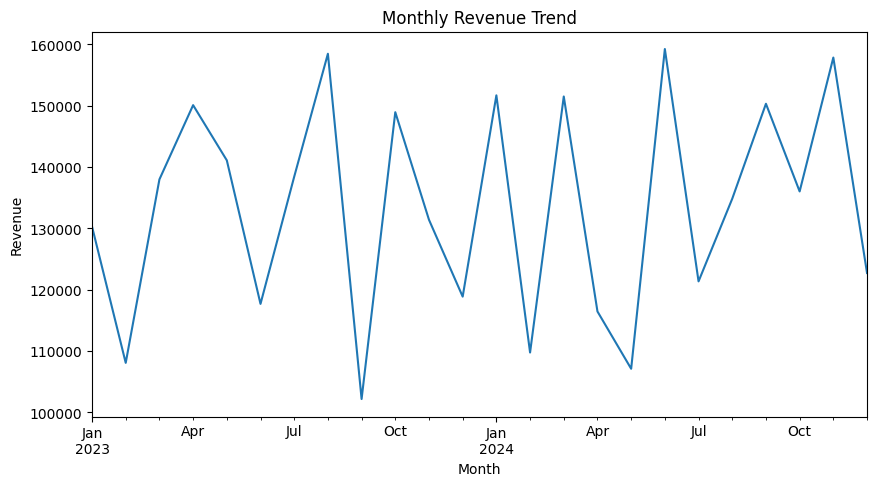

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_trend.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [9]:
customer_revenue = staging_df.groupby("CustomerID")["Revenue"].sum()

customer_revenue = customer_revenue.reset_index()

customer_revenue["Segment"] = np.random.choice(["Bronze","Silver","Gold"], len(customer_revenue))

segment_revenue = customer_revenue.groupby("Segment")["Revenue"].sum()

segment_revenue

,Revenue
Segment,
Bronze,1.029190e+06
Gold,1.012929e+06
Silver,1.159946e+06


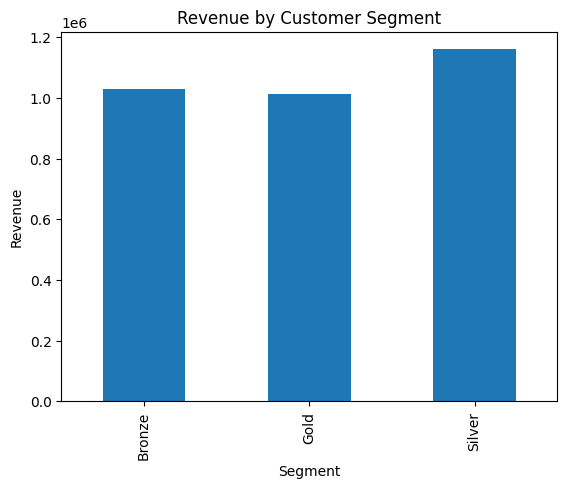

In [10]:
segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")

plt.show()

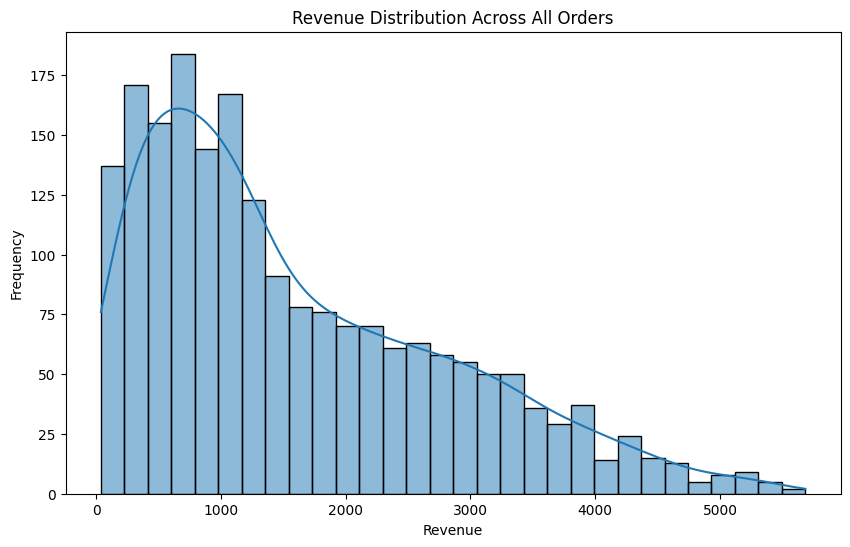

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(staging_df["Revenue"], bins=30, kde=True)

plt.title("Revenue Distribution Across All Orders")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

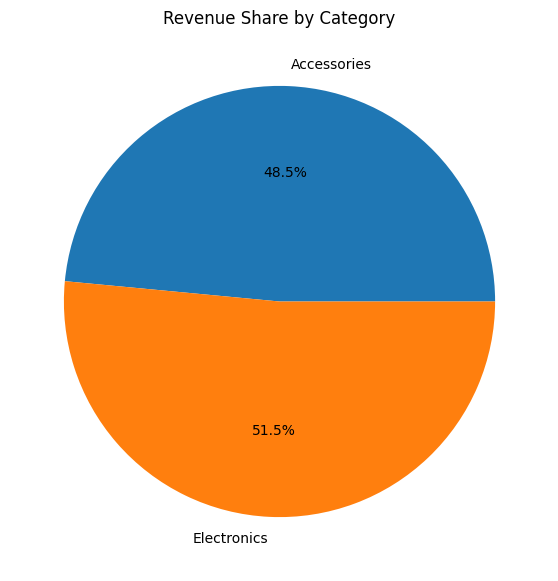

In [12]:
category_revenue = staging_df.groupby("Category")["Revenue"].sum()

plt.figure(figsize=(7,7))
plt.pie(category_revenue, labels=category_revenue.index, autopct="%1.1f%%")

plt.title("Revenue Share by Category")

plt.show()

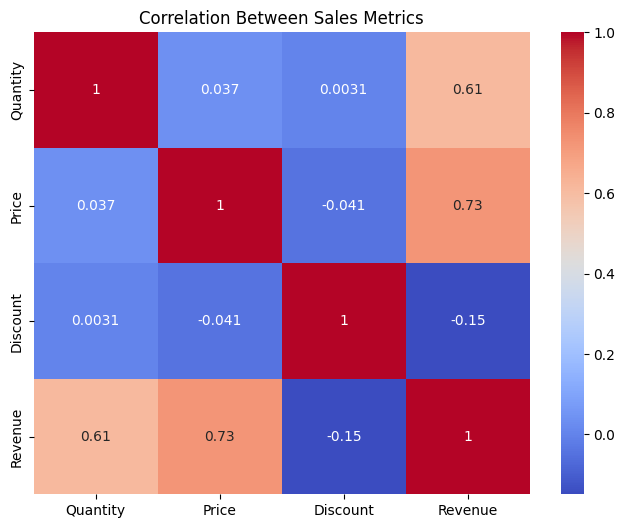

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    staging_df[["Quantity","Price","Discount","Revenue"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Sales Metrics")

plt.show()

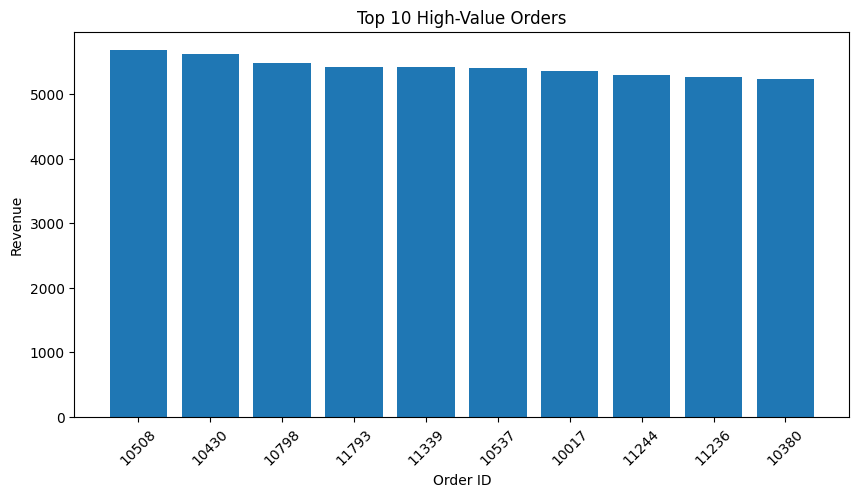

In [14]:
top_orders = staging_df.sort_values(by="Revenue", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_orders["OrderID"].astype(str), top_orders["Revenue"])

plt.title("Top 10 High-Value Orders")
plt.xlabel("Order ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [15]:
print("=== DATA ENGINEERING PIPELINE SUMMARY ===")
print("\nRaw Data Shape:", df.shape)
print("Staging Data Shape:", staging_df.shape)
print("Fact Table Shape:", fact_sales.shape)
print("Customer Dimension Shape:", dim_customer.shape)
print("Product Dimension Shape:", dim_product.shape)

print("\nTotal Revenue:", staging_df["Revenue"].sum())
print("Total Orders:", len(staging_df))
print("Unique Customers:", staging_df["CustomerID"].nunique())

=== DATA ENGINEERING PIPELINE SUMMARY ===

Raw Data Shape: (2000, 12)
Staging Data Shape: (2000, 12)
Fact Table Shape: (2000, 8)
Customer Dimension Shape: (200, 2)
Product Dimension Shape: (1141, 3)

Total Revenue: 3202065.2370166928
Total Orders: 2000
Unique Customers: 200


In [16]:
staging_df.to_csv("staging_data.csv", index=False)
fact_sales.to_csv("fact_sales.csv", index=False)
dim_customer.to_csv("dim_customer.csv", index=False)
dim_product.to_csv("dim_product.csv", index=False)
dim_date.to_csv("dim_date.csv", index=False)

In [17]:
summary = pd.DataFrame({
    "Layer": ["Raw Data", "Staging", "Fact Table", "Dimension Tables"],
    "Rows": [
        len(df),
        len(staging_df),
        len(fact_sales),
        len(dim_customer) + len(dim_product) + len(dim_date)
    ]
})

summary

,Layer,Rows
0,Raw Data,2000
1,Staging,2000
2,Fact Table,2000
3,Dimension Tables,2025


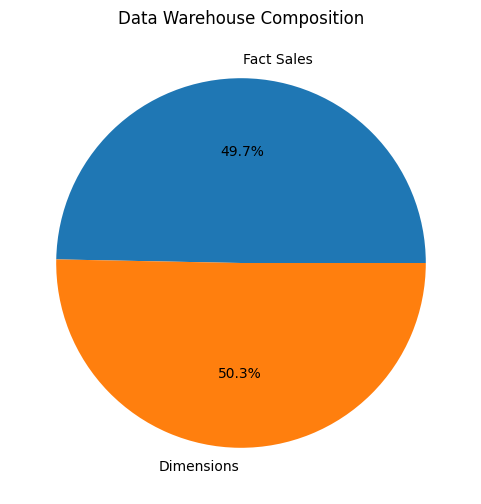

In [18]:
plt.figure(figsize=(6,6))

labels = ["Fact Sales", "Dimensions"]
values = [len(fact_sales), len(dim_customer)+len(dim_product)+len(dim_date)]

plt.pie(values, labels=labels, autopct="%1.1f%%")

plt.title("Data Warehouse Composition")

plt.show()